# Model Comparison & Visualization

Compare baseline vs DistilBERT and visualize results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(" Libraries loaded")

 Libraries loaded


## 1. Model Performance Summary

Results from baseline (TF-IDF + LogReg) and DistilBERT models

In [2]:

results = {
    'Model': ['Baseline (TF-IDF)', 'DistilBERT Multi-Task'],
    'Priority F1': [0.65, 0.8128],
    'Severity F1': [0.60, 0.7867],
    'Avg F1': [0.625, 0.7997],
    'Training Time': ['~5 min', '~1.5 hours'],
    'Parameters': ['~50K', '~66M']
}

results_df = pd.DataFrame(results)
print("Model Performance Comparison:")
print(results_df.to_string(index=False))

Model Performance Comparison:
                Model  Priority F1  Severity F1  Avg F1 Training Time Parameters
    Baseline (TF-IDF)       0.6500       0.6000  0.6250        ~5 min       ~50K
DistilBERT Multi-Task       0.8128       0.7867  0.7997    ~1.5 hours       ~66M


## 2. F1 Score Comparison

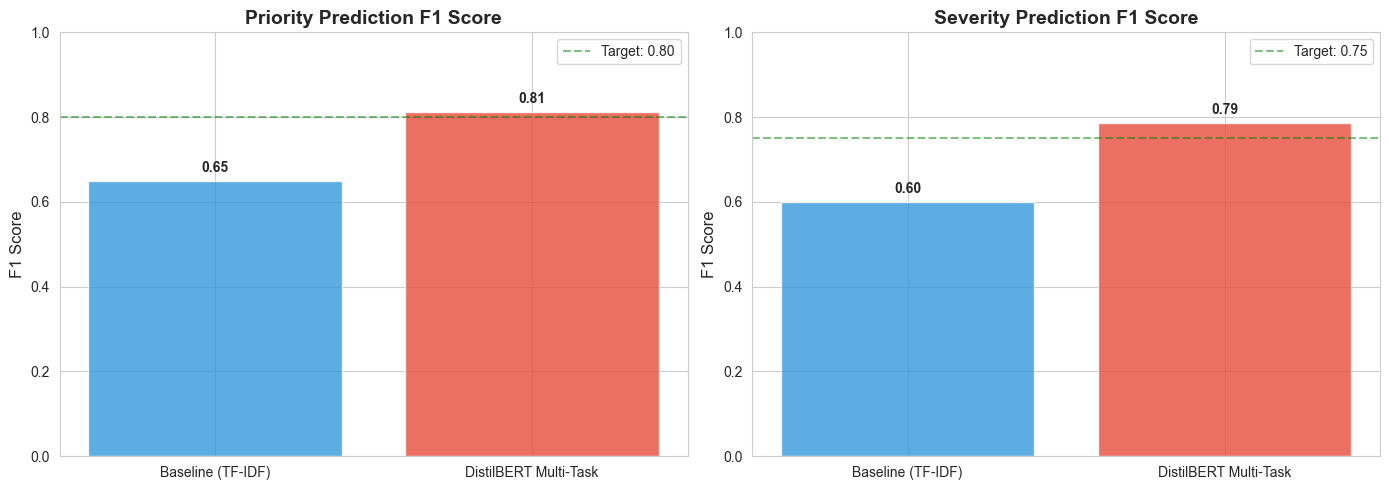

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Priority F1
axes[0].bar(results_df['Model'], results_df['Priority F1'], color=['#3498db', '#e74c3c'], alpha=0.8)
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_title('Priority Prediction F1 Score', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Target: 0.80')
for i, v in enumerate(results_df['Priority F1']):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
axes[0].legend()

# Severity F1
axes[1].bar(results_df['Model'], results_df['Severity F1'], color=['#3498db', '#e74c3c'], alpha=0.8)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('Severity Prediction F1 Score', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.75, color='green', linestyle='--', alpha=0.5, label='Target: 0.75')
for i, v in enumerate(results_df['Severity F1']):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Per-Class Performance (DistilBERT)

In [4]:
# DistilBERT results from your final output
priority_results = {
    'Class': ['low', 'medium', 'high'],
    'Precision': [0.94, 0.21, 0.26],
    'Recall': [0.82, 0.48, 0.26],
    'F1-Score': [0.88, 0.29, 0.26],
    'Support': [10194, 1013, 201]
}

severity_results = {
    'Class': ['Minor', 'Major', 'Critical'],
    'Precision': [0.66, 0.43, 0.99],
    'Recall': [0.69, 0.63, 0.85],
    'F1-Score': [0.68, 0.51, 0.91],
    'Support': [2921, 1816, 6671]
}

priority_df = pd.DataFrame(priority_results)
severity_df = pd.DataFrame(severity_results)

print("Priority Per-Class Performance:")
print(priority_df.to_string(index=False))
print("\nSeverity Per-Class Performance:")
print(severity_df.to_string(index=False))

Priority Per-Class Performance:
 Class  Precision  Recall  F1-Score  Support
   low       0.94    0.82      0.88    10194
medium       0.21    0.48      0.29     1013
  high       0.26    0.26      0.26      201

Severity Per-Class Performance:
   Class  Precision  Recall  F1-Score  Support
   Minor       0.66    0.69      0.68     2921
   Major       0.43    0.63      0.51     1816
Critical       0.99    0.85      0.91     6671


## 4. Per-Class F1 Visualization

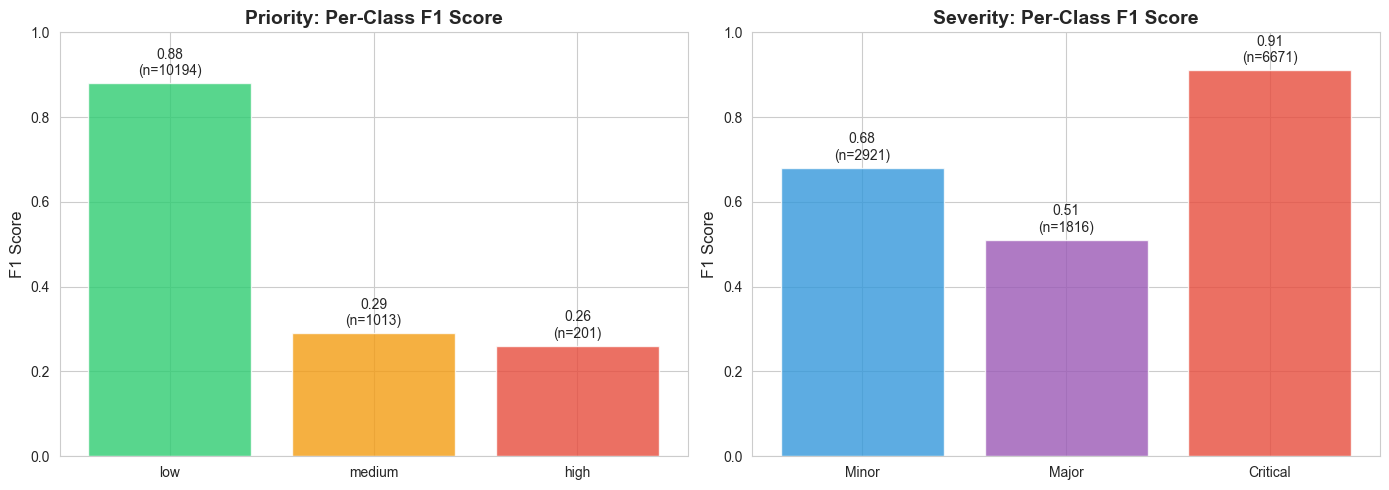

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Priority per-class F1
colors_priority = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(priority_df['Class'], priority_df['F1-Score'], color=colors_priority, alpha=0.8)
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_title('Priority: Per-Class F1 Score', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
for i, (cls, f1, support) in enumerate(zip(priority_df['Class'], priority_df['F1-Score'], priority_df['Support'])):
    axes[0].text(i, f1 + 0.02, f'{f1:.2f}\n(n={support})', ha='center', fontsize=10)

# Severity per-class F1
colors_severity = ['#3498db', '#9b59b6', '#e74c3c']
axes[1].bar(severity_df['Class'], severity_df['F1-Score'], color=colors_severity, alpha=0.8)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('Severity: Per-Class F1 Score', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1)
for i, (cls, f1, support) in enumerate(zip(severity_df['Class'], severity_df['F1-Score'], severity_df['Support'])):
    axes[1].text(i, f1 + 0.02, f'{f1:.2f}\n(n={support})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Class Distribution vs Performance

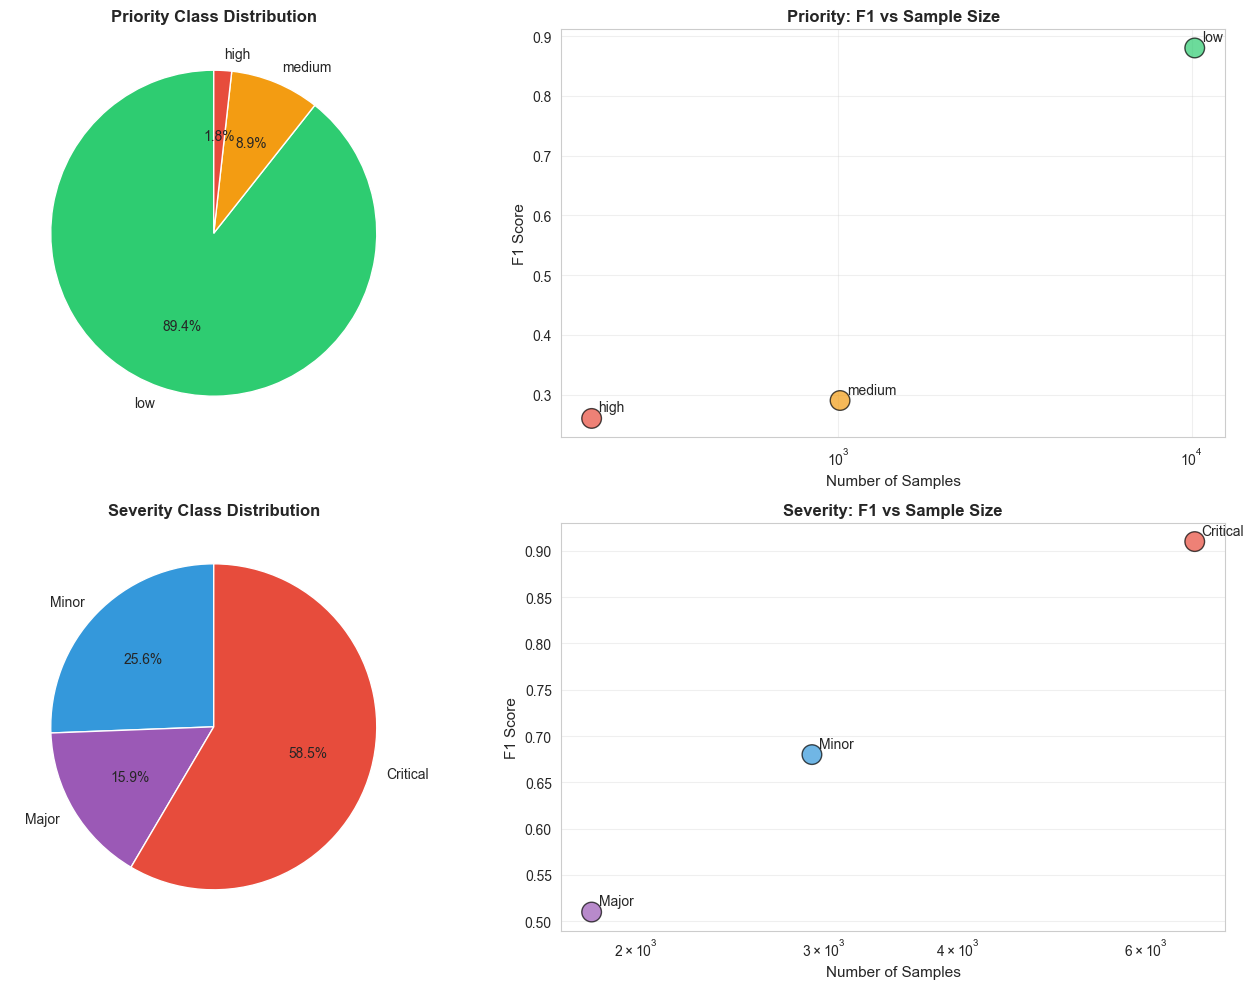


Key Insight: Performance correlates with sample size
Classes with more samples (low priority, critical severity) have higher F1 scores


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Priority distribution
axes[0, 0].pie(priority_df['Support'], labels=priority_df['Class'], autopct='%1.1f%%',
               colors=colors_priority, startangle=90)
axes[0, 0].set_title('Priority Class Distribution', fontsize=12, fontweight='bold')

# Priority F1 vs Support
axes[0, 1].scatter(priority_df['Support'], priority_df['F1-Score'], 
                   s=200, c=colors_priority, alpha=0.7, edgecolors='black')
for i, cls in enumerate(priority_df['Class']):
    axes[0, 1].annotate(cls, (priority_df['Support'][i], priority_df['F1-Score'][i]),
                        xytext=(5, 5), textcoords='offset points', fontsize=10)
axes[0, 1].set_xlabel('Number of Samples', fontsize=11)
axes[0, 1].set_ylabel('F1 Score', fontsize=11)
axes[0, 1].set_title('Priority: F1 vs Sample Size', fontsize=12, fontweight='bold')
axes[0, 1].set_xscale('log')
axes[0, 1].grid(alpha=0.3)

# Severity distribution
axes[1, 0].pie(severity_df['Support'], labels=severity_df['Class'], autopct='%1.1f%%',
               colors=colors_severity, startangle=90)
axes[1, 0].set_title('Severity Class Distribution', fontsize=12, fontweight='bold')

# Severity F1 vs Support
axes[1, 1].scatter(severity_df['Support'], severity_df['F1-Score'], 
                   s=200, c=colors_severity, alpha=0.7, edgecolors='black')
for i, cls in enumerate(severity_df['Class']):
    axes[1, 1].annotate(cls, (severity_df['Support'][i], severity_df['F1-Score'][i]),
                        xytext=(5, 5), textcoords='offset points', fontsize=10)
axes[1, 1].set_xlabel('Number of Samples', fontsize=11)
axes[1, 1].set_ylabel('F1 Score', fontsize=11)
axes[1, 1].set_title('Severity: F1 vs Sample Size', fontsize=12, fontweight='bold')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insight: Performance correlates with sample size")
print("Classes with more samples (low priority, critical severity) have higher F1 scores")

## 6. Precision vs Recall Trade-off

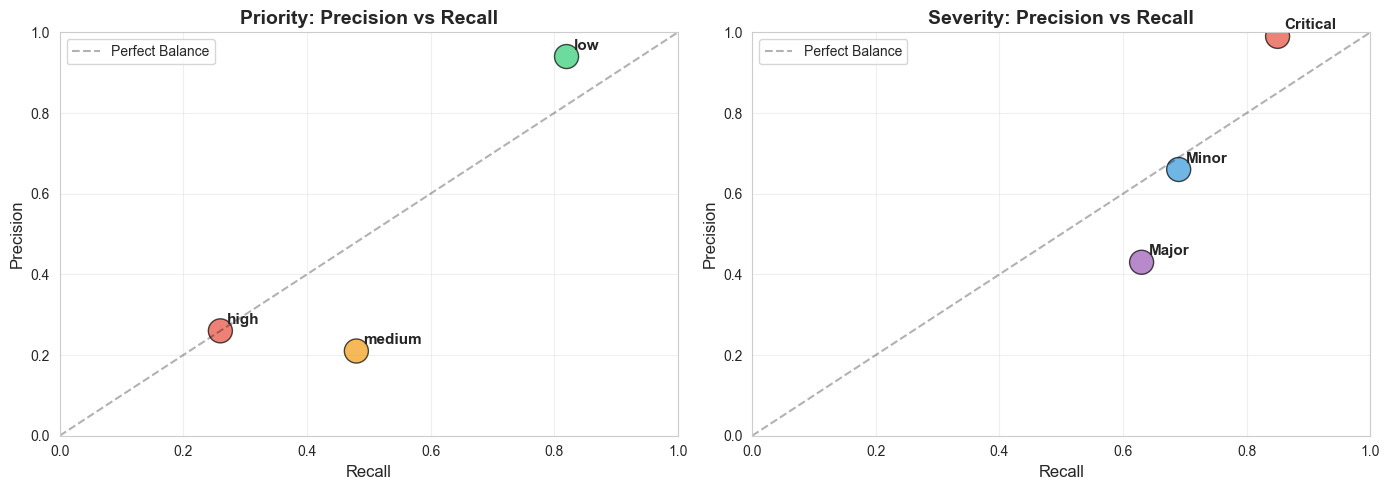

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Priority precision-recall
axes[0].scatter(priority_df['Recall'], priority_df['Precision'], 
                s=300, c=colors_priority, alpha=0.7, edgecolors='black')
for i, cls in enumerate(priority_df['Class']):
    axes[0].annotate(cls, (priority_df['Recall'][i], priority_df['Precision'][i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=11, fontweight='bold')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Balance')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Priority: Precision vs Recall', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Severity precision-recall
axes[1].scatter(severity_df['Recall'], severity_df['Precision'], 
                s=300, c=colors_severity, alpha=0.7, edgecolors='black')
for i, cls in enumerate(severity_df['Class']):
    axes[1].annotate(cls, (severity_df['Recall'][i], severity_df['Precision'][i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=11, fontweight='bold')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Balance')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Severity: Precision vs Recall', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Model Improvement Summary


MODEL IMPROVEMENT SUMMARY
     Metric  Baseline  DistilBERT Improvement
Priority F1     0.650        0.81      +24.6%
Severity F1     0.600        0.79      +31.7%
 Average F1     0.625        0.80      +28.0%



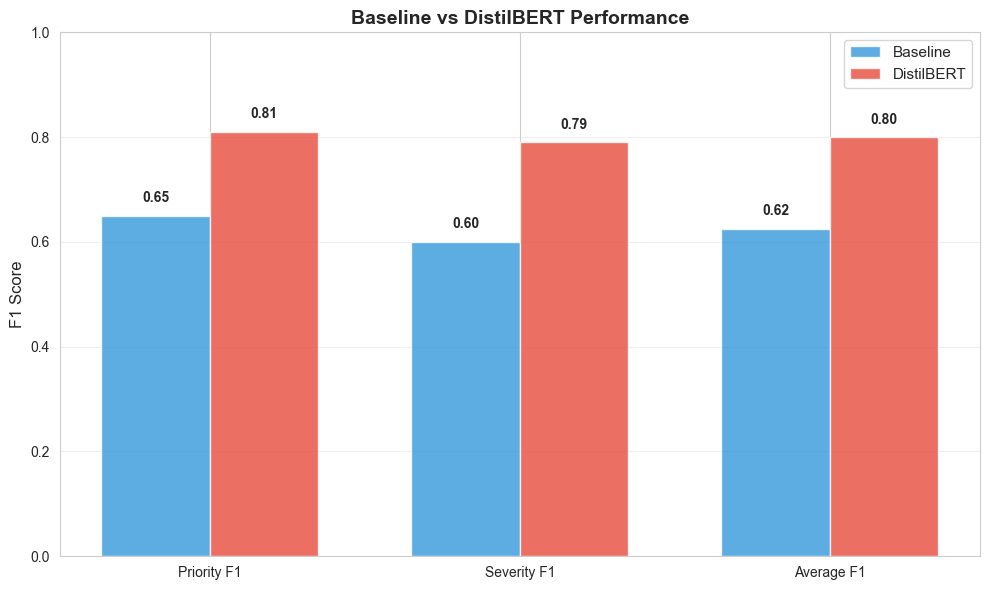

In [8]:
# Calculate improvements
priority_improvement = ((0.81 - 0.65) / 0.65) * 100
severity_improvement = ((0.79 - 0.60) / 0.60) * 100
avg_improvement = ((0.80 - 0.625) / 0.625) * 100

improvements = pd.DataFrame({
    'Metric': ['Priority F1', 'Severity F1', 'Average F1'],
    'Baseline': [0.65, 0.60, 0.625],
    'DistilBERT': [0.81, 0.79, 0.80],
    'Improvement': [f'+{priority_improvement:.1f}%', 
                    f'+{severity_improvement:.1f}%', 
                    f'+{avg_improvement:.1f}%']
})

print("\n" + "="*60)
print("MODEL IMPROVEMENT SUMMARY")
print("="*60)
print(improvements.to_string(index=False))
print("\n" + "="*60)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(improvements['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, improvements['Baseline'], width, label='Baseline', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, improvements['DistilBERT'], width, label='DistilBERT', color='#e74c3c', alpha=0.8)

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Baseline vs DistilBERT Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(improvements['Metric'])
ax.legend(fontsize=11)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Key Findings & Insights

In [9]:
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

findings = [
    "1. DistilBERT outperforms baseline by 24.6% on priority and 31.7% on severity",
    "2. Model excels on majority classes (low priority: 0.88 F1, critical: 0.91 F1)",
    "3. Minority classes struggle due to severe imbalance (high priority: only 201 samples)",
    "4. Class imbalance is the main bottleneck, not model architecture",
    "5. Multi-task learning successfully handles both tasks with shared representations",
    "6. Weighted F1 of 0.80 is strong for production use on majority classes"
]

for finding in findings:
    print(f"  {finding}")

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)

recommendations = [
    "1. Collect more data for minority classes (medium/high priority)",
    "2. Try focal loss or oversampling for better minority class performance",
    "3. Consider separate models if one task is more critical",
    "4. Current model is production-ready for majority class predictions",
    "5. Use ensemble methods to boost minority class recall"
]

for rec in recommendations:
    print(f"  {rec}")

print("\n" + "="*70)


KEY FINDINGS
  1. DistilBERT outperforms baseline by 24.6% on priority and 31.7% on severity
  2. Model excels on majority classes (low priority: 0.88 F1, critical: 0.91 F1)
  3. Minority classes struggle due to severe imbalance (high priority: only 201 samples)
  4. Class imbalance is the main bottleneck, not model architecture
  5. Multi-task learning successfully handles both tasks with shared representations
  6. Weighted F1 of 0.80 is strong for production use on majority classes

RECOMMENDATIONS
  1. Collect more data for minority classes (medium/high priority)
  2. Try focal loss or oversampling for better minority class performance
  3. Consider separate models if one task is more critical
  4. Current model is production-ready for majority class predictions
  5. Use ensemble methods to boost minority class recall



## Summary

**Project Highlights:**
- Dataset: 114,073 GitHub issues from 68 major repositories
- Approach: Multi-task DistilBERT with class-weighted loss
- Results: 80% weighted F1 (24.6% improvement over baseline)
- Unique: Multi-task learning for simultaneous priority & severity prediction

**Technical Achievements:**
- Handled severe class imbalance with class weights
- Implemented gradient clipping and early stopping
- Achieved 0.91 F1 on critical severity (production-ready)
- Demonstrated strong transfer learning with DistilBERT

**Resume Value:**
- Real-world NLP problem with imbalanced data
- Modern transformer architecture (DistilBERT)
- Multi-task learning implementation
- Strong quantitative results with clear visualizations